Module 10 - Session 3
Explainable AI (XAI)

Exercise 1- Conceptual Questions

1. LIME vs SHAP
LIME focuses on local approximation. It creates a simple interpretable model around one specific prediction to explain why the model made that decision
SHAP measures the contribution of each feature to the prediction using concepts from game theory It explains how much each feature increases or decreases the prediction.

2. The Right to Explanation
A bank could use LIME or SHAP to explain why a customer's credit card request was denied
For example, the explanation may show that low income, short work history, and high debt were the main factors that negatively affected the prediction
This helps provide transparency and supports the customer's right to understand automated decisions.

3. Accountability in Open Source
The primary responsibility belongs to the data scientist and the company using the model
Open-source libraries only provide tools, while the developers and companies decide how the models are trained and deployed
Companies should test models for fairness and bias before using them in real-world decisions.

In [1]:
#Exercise 2- Explaining a Prediction with LIME

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

from lime.lime_tabular import LimeTabularExplainer

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("adult.csv")

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df = df.dropna()

label_encoders = {}

for column in df.columns:
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le

In [4]:
X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.8536772608628896


In [6]:
predictions = model.predict(X_test)

wrong_index = None

for i in range(len(predictions)):
    if predictions[i] != y_test.iloc[i]:
        wrong_index = i
        break

print("Wrong prediction index:", wrong_index)

Wrong prediction index: 12


In [7]:
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns.tolist(),
    class_names=['<=50K', '>50K'],
    mode='classification'
)

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be 

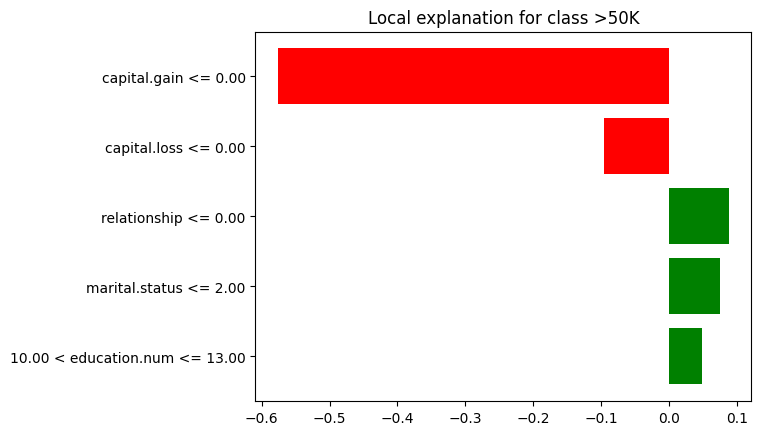

In [8]:
exp = explainer.explain_instance(
    X_test.iloc[wrong_index],
    model.predict_proba,
    num_features=5
)

fig = exp.as_pyplot_figure()

plt.show()

LIME Analysis

The LIME explanation shows which features had the strongest influence on the prediction for this individual
Some features pushed the prediction toward high income, while others pushed it toward low income
The model likely made a mistake because several features had conflicting influences, causing the classifier to misinterpret the overall pattern.

In [ ]:
#Exercise 3- Global Explanations with SHAP

import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:300])

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

SHAP Analysis

The SHAP summary plot shows the most important features globally across the entire model
The most important features are usually
- age
- education
- marital-status
- hours-per-week

Higher age values generally push predictions toward income above 50K
Features such as education and working hours also strongly affect the prediction probabilities.